# Chess Move Transformer — v4
### Square-token encoder + Geometric Attention Bias + bilinear from/to policy head

---

## What this is

v1–v3 were **decoder-only sequence models**: a game is a sequence of move tokens, and the board (in
v3) was injected by flattening it to a 1167-dim vector and pushing it through one `nn.Linear`. That
flat projection is exactly what broke in v3 — 132 features summing through one matrix arrived at
12.4x the token embedding and took 98.5% of the input variance.

v4 changes the framing. It is an **encoder-only model over a single position**, in the style Leela
Chess Zero's transformer bodies and the Maia line use:

| | v1–v3 | v4 |
|---|---|---|
| Framing | autoregressive over move history | positional: one position -> one move |
| Board input | flat 781/1167-dim vector -> `Linear` | **64 square tokens**, self-attention between them |
| Spatial structure | hand-fed (`USE_ATTACK_MAPS`, `USE_LEGAL_FROM_TO`) | native, via attention + geometric bias |
| Positional encoding | learned per-ply embedding | **Geometric Attention Bias** over square pairs |
| Output | flat softmax over 4,546 UCI tokens | **bilinear from-square x to-square** + promotion head |
| Context limit | `BLOCK_SIZE = 160` plies, longer games truncated | none — no sequence axis to truncate |

## Attribution and a caveat

This follows the architectural direction described for Chessformer / Maia-3 (ICLR 2026). **I could
not verify that paper's exact formulation**, so `GeometricAttentionBias` below is my own
implementation of the idea, not a reproduction of theirs: a learned 2D relative-position bias
bucketed by `(delta_file, delta_rank)`, added to the attention logits. That is the Swin Transformer
relative-bias construction applied to the chessboard, and it expresses same-rank / same-file /
diagonal / knight-move relationships without any of them being hand-coded. If you have the paper,
compare Section 7 against their GAB definition before citing this as theirs.

The other two pillars — 64 squares as tokens, and an attention-based source/destination policy head
— are long-established in Lc0's transformer nets and are not specific to that paper.

## What this does *not* fix

Data. At 12k games this is still ~0.2 tokens per parameter. The architecture should buy **sample
efficiency** — a better inductive bias helps most exactly when data is scarce — but the published
57%-range numbers come from millions of games. Expect v4 to raise the ceiling, not to reach it.

## Notebook Structure

| # | Section |
|---|---|
| 1 | Setup & Config |
| 2 | Load Games -> Records |
| 3 | Game-Level Split |
| 4 | Move Vocabulary + (from, to, promotion) decomposition |
| 5 | Position Feature Extraction — square tokens |
| 6 | Dataset & DataLoader — position-level, zero padding |
| 7 | Model — square-token encoder, GAB, bilinear policy head |
| 8 | Training |
| 9 | Legal-Move-Masked Evaluation |
| 10 | Save Artifacts |
| 11 | Summary & Next Steps |

In [2]:
!pip install chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 70.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=3e44b269cdd4e6b5f4a9049b5aec4b789042fe86e94e754e1af8bdd1e42bbfc5
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


---
# 1. Setup & Config

In [15]:
import os
import re
import json
import math
import random
import time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import chess
import chess.pgn
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print("Using device:", device)

Using device: cuda


In [16]:
# ----- Data -------------------------------------------------------------
PGN_PATHS = ["lichess_elite_2019-10.pgn"]

MIN_ELO, MAX_ELO     = 2200, 2600
MAX_GAMES            = 15000     # <-- still the biggest lever available
MIN_MOVES, MAX_MOVES = 8, 200
# NOTE: there is no BLOCK_SIZE. v4 has no sequence axis, so long games are not truncated.

# ----- Architecture -----------------------------------------------------
D_MODEL, N_HEAD, N_LAYER = 256, 8, 8
DROPOUT                  = 0.1
EMB_INIT_STD             = 0.02

USE_GAB      = True    # geometric attention bias; False -> plain attention, for ablation
USE_HISTORY  = True    # K past moves as extra tokens
K_HISTORY    = 8

# Hand-fed per-square spatial features (attacked-by, legal-from/to), the v3 approach.
# Default OFF: v4's whole thesis is that attention + GAB derive this natively. Turning it
# on is experiment #2, and the delta is the direct test of that thesis.
USE_SQUARE_AUX = False

# ----- Training ---------------------------------------------------------
GAMES_PER_BATCH     = 8      # ~650 positions/batch at mean game length; lower it if OOM
LR                  = 3e-4
WEIGHT_DECAY        = 0.01
N_EPOCHS            = 5
EARLY_STOP_PATIENCE = 4
NUM_WORKERS         = 0      # keep 0 on Windows/Jupyter; 4 is good on Mac/Linux

# ----- Evaluation -------------------------------------------------------
EVAL_MAX_GAMES = 1500

# ----- Output -----------------------------------------------------------
CKPT_PATH  = "chess_gpt_v4.pt"
VOCAB_PATH = "chess_move_vocab_v4.json"

---
# 2. Load Games → Records

Identical to v3's loader, and for the same reasons: compact dicts instead of `chess.pgn.Game`
objects so RAM stops capping the dataset, multi-file input via `PGN_PATHS`, and the same set of
**safe** headers only.

`Result`, `WhiteRatingDiff` / `BlackRatingDiff`, `Termination`, `ECO` and `Opening` are still
deliberately not read — every one of them is future information relative to the move being
predicted. `WhiteElo`, `BlackElo` and `TimeControl` are known before move 1 and are the only ones
used.

In [17]:
CLK_RE = re.compile(r"\[%clk\s+(\d+):(\d+):(\d+(?:\.\d+)?)\]")
TC_RE  = re.compile(r"^(\d+)(?:\+(\d+))?")


def parse_clock(comment):
    m = CLK_RE.search(comment or "")
    if not m:
        return None
    return int(m.group(1)) * 3600 + int(m.group(2)) * 60 + float(m.group(3))


def parse_time_control(headers):
    m = TC_RE.match(headers.get("TimeControl", "") or "")
    if not m:
        return None, 0.0
    base = float(m.group(1))
    inc = float(m.group(2)) if m.group(2) else 0.0
    return (base if base > 0 else None), inc


def game_to_record(game):
    try:
        w_elo = int(game.headers.get("WhiteElo", 0))
        b_elo = int(game.headers.get("BlackElo", 0))
    except ValueError:
        return None
    if not (MIN_ELO <= w_elo <= MAX_ELO and MIN_ELO <= b_elo <= MAX_ELO):
        return None

    ucis, clocks = [], []
    for node in game.mainline():
        ucis.append(node.move.uci())
        clocks.append(parse_clock(node.comment))

    if not (MIN_MOVES <= len(ucis) <= MAX_MOVES):
        return None

    base, inc = parse_time_control(game.headers)
    return {"uci": ucis, "w": w_elo, "b": b_elo, "clk": clocks, "base": base, "inc": inc}


records = []
t0 = time.time()

for path in PGN_PATHS:
    if not os.path.exists(path):
        print(f"!! Missing PGN, skipping: {path}")
        continue
    print(f"Reading {path} ...")
    with open(path, encoding="utf-8", errors="replace") as f:
        pbar = tqdm(total=MAX_GAMES, initial=len(records), desc=os.path.basename(path))
        while len(records) < MAX_GAMES:
            game = chess.pgn.read_game(f)
            if game is None:
                break
            rec = game_to_record(game)
            if rec is not None:
                records.append(rec)
                pbar.update(1)
        pbar.close()
    if len(records) >= MAX_GAMES:
        break

n_with_clocks = sum(1 for r in records if r["base"] and any(c is not None for c in r["clk"]))
HAS_CLOCK_DATA = n_with_clocks > 0
n_positions = sum(len(r["uci"]) for r in records)

print(f"\nGames loaded: {len(records)}  ({time.time() - t0:.1f}s)")
print(f"Training positions available: {n_positions:,}")
print(f"Games with usable clock data: {n_with_clocks} ({100 * n_with_clocks / max(1, len(records)):.1f}%)")

tc_counts = Counter((r["base"], r["inc"]) for r in records)
print("\nTime controls (base+inc -> games):")
for (base, inc), n in tc_counts.most_common(6):
    print(f"  {(f'{int(base)}+{int(inc)}' if base else 'unknown'):>12}  {n}")

Reading lichess_elite_2019-10.pgn ...


lichess_elite_2019-10.pgn: 100%|██████████| 15000/15000 [00:47<00:00, 318.38it/s]



Games loaded: 15000  (47.2s)
Training positions available: 1,222,910
Games with usable clock data: 0 (0.0%)

Time controls (base+inc -> games):
         180+0  13164
         180+2  1335
         300+0  379
         120+3  44
         600+0  36
         180+1  17


---
# 3. Game-Level Train/Test Split

Split by **game**, same `SEED` as v1–v3. This matters more in v4, not less: positions are now
independent training examples, so a position-level split would put sibling positions from the same
game on both sides and inflate every number below.

In [18]:
train_records, test_records = train_test_split(records, test_size=0.2, random_state=SEED)
print(f"Train games: {len(train_records)}  ({sum(len(r['uci']) for r in train_records):,} positions)")
print(f"Test games:  {len(test_records)}  ({sum(len(r['uci']) for r in test_records):,} positions)")

Train games: 12000  (977,679 positions)
Test games:  3000  (245,231 positions)


---
# 4. Move Vocabulary + (from, to, promotion) Decomposition

The vocabulary is byte-for-byte v1–v3's full UCI action space, kept **only so the evaluation and
legal-masking code stays directly comparable across all four notebooks**. v4 never embeds it.

What is new is the decomposition. Every move token is split into `(from_square, to_square,
promotion)`, which is what lets the policy head be bilinear instead of a flat 4,546-way softmax:

```
logit(move) = q[from] . k[to] / sqrt(d)        + promotion_bias[to, piece]  (promotions only)
```

Moves that share a from-square or a to-square now share parameters, which is the sample-efficiency
argument the v2/v3 notebooks flagged as a future lever. Note that both `e7e8` and `e7e8q` exist in
the vocabulary and both can be legal (a rook and a pawn respectively) — the decomposition handles
each, the plain move simply carries no promotion bias.

In [19]:
PROMOTION_PIECES = [chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT]
PROMO_INDEX = {pc: i for i, pc in enumerate(PROMOTION_PIECES)}   # queen=0 ... knight=3
N_PROMO = len(PROMOTION_PIECES)


def generate_full_uci_vocab():
    moves = set()
    for from_sq in chess.SQUARES:
        for to_sq in chess.SQUARES:
            if from_sq == to_sq:
                continue
            from_rank, to_rank = chess.square_rank(from_sq), chess.square_rank(to_sq)
            is_promotion_rank = (from_rank == 6 and to_rank == 7) or (from_rank == 1 and to_rank == 0)
            moves.add(chess.Move(from_sq, to_sq).uci())
            if is_promotion_rank:
                for promo in PROMOTION_PIECES:
                    moves.add(chess.Move(from_sq, to_sq, promotion=promo).uci())
    return sorted(moves)


SPECIAL_TOKENS = ["<PAD>", "<BOS>"]     # kept for vocab-index parity with v1-v3
itos = SPECIAL_TOKENS + generate_full_uci_vocab()
stoi = {tok: i for i, tok in enumerate(itos)}
VOCAB_SIZE = len(itos)
N_SPECIAL = len(SPECIAL_TOKENS)

# --- decomposition tables, built once ---
MOVE_FROM  = np.zeros(VOCAB_SIZE, dtype=np.int64)
MOVE_TO    = np.zeros(VOCAB_SIZE, dtype=np.int64)
MOVE_PROMO = np.full(VOCAB_SIZE, -1, dtype=np.int64)     # -1 = not a promotion

for i in range(N_SPECIAL, VOCAB_SIZE):
    mv = chess.Move.from_uci(itos[i])
    MOVE_FROM[i] = mv.from_square
    MOVE_TO[i] = mv.to_square
    if mv.promotion is not None:
        MOVE_PROMO[i] = PROMO_INDEX[mv.promotion]

# Flat index into a (64*64) from-to logit matrix, and into a (64*N_PROMO) promotion matrix.
MOVE_FT       = MOVE_FROM * 64 + MOVE_TO
MOVE_PROMO_FT = np.where(MOVE_PROMO >= 0, MOVE_TO * N_PROMO + np.maximum(MOVE_PROMO, 0), 0)
IS_PROMO      = MOVE_PROMO >= 0

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Promotion tokens: {IS_PROMO.sum()}  |  plain move tokens: {VOCAB_SIZE - N_SPECIAL - IS_PROMO.sum()}")

# Round-trip check: decomposition must rebuild every UCI string exactly.
for i in range(N_SPECIAL, VOCAB_SIZE):
    promo = PROMOTION_PIECES[MOVE_PROMO[i]] if MOVE_PROMO[i] >= 0 else None
    assert chess.Move(MOVE_FROM[i], MOVE_TO[i], promotion=promo).uci() == itos[i], itos[i]
print("(from, to, promotion) decomposition round-trips for every token.")

Vocabulary size: 4546
Promotion tokens: 512  |  plain move tokens: 4032
(from, to, promotion) decomposition round-trips for every token.


---
# 5. Position Feature Extraction — Square Tokens

Each position becomes **64 square tokens plus a small number of global tokens**. There is no flat
board vector anywhere in v4, which is what makes the v3 scale-imbalance failure structurally
impossible: nothing sums 132 features through a single matrix.

| Token group | Count | Contents |
|---|---|---|
| Squares | 64 | piece-and-colour id (0 = empty, 1–12) + learned square identity |
| State | 1 | side to move, 4 castling rights, 8-dim en-passant file |
| Skill | 1 | side-to-move ELO, opponent ELO, clocks, time control |
| History | `K_HISTORY` | the last K moves, each as `from`-square + `to`-square + recency |

**Alignment is simpler than v1–v3 and much harder to get wrong.** There is no shift: the features at
index `t` are the position *before* move `t`, and the target is move `t` itself. No `<BOS>`, no
`ids[t+1]`.

History moves are encoded as **square embeddings**, not move-vocabulary embeddings. That keeps the
model square-centric throughout and avoids reintroducing a 4,546 x 256 embedding table (1.2M
parameters) purely to describe eight past moves.

`USE_SQUARE_AUX` optionally attaches v3's hand-fed spatial features (attacked-by-white/black,
legal-from, legal-to) as 4 extra binary features **per square token** — which is a much more natural
home for them than a flat vector. It defaults off so the first v4 run is a clean test of whether
attention plus GAB derives that structure on its own.

In [20]:
# piece id: 0 = empty, 1-6 = white P N B R Q K, 7-12 = black P N B R Q K
PIECE_ID = {}
for _ci, _color in enumerate((chess.WHITE, chess.BLACK)):
    for _pi, _pt in enumerate((chess.PAWN, chess.KNIGHT, chess.BISHOP,
                               chess.ROOK, chess.QUEEN, chess.KING)):
        PIECE_ID[(_color, _pt)] = 1 + _ci * 6 + _pi
N_PIECE_IDS = 13

STATE_DIM = 1 + 4 + 8      # side to move, castling, ep file
META_DIM  = 7              # elo_stm, elo_opp, clk_stm, clk_opp, has_clk, tc_base, tc_inc
AUX_DIM   = 4              # per square: attacked-by-W, attacked-by-B, legal-from, legal-to
NO_SQUARE = 64             # sentinel index for "no move here yet" in history

ELO_SPAN = max(1, MAX_ELO - MIN_ELO)
_TC_LOG_MAX = math.log1p(10800.0)


def build_meta_features(rec, T):
    """(T, META_DIM). Identical semantics to v3, including the causal clock lag."""
    meta = np.zeros((T, META_DIM), dtype=np.float32)
    e_w = (rec["w"] - MIN_ELO) / ELO_SPAN
    e_b = (rec["b"] - MIN_ELO) / ELO_SPAN
    base, clks = rec["base"], rec["clk"]
    has_clk = 1.0 if (base and any(c is not None for c in clks)) else 0.0
    tc_base = min(1.0, math.log1p(base) / _TC_LOG_MAX) if base else 0.0
    tc_inc = min(1.0, rec.get("inc", 0.0) / 60.0)

    for t in range(T):
        white_to_move = (t % 2 == 0)
        meta[t, 0] = e_w if white_to_move else e_b
        meta[t, 1] = e_b if white_to_move else e_w
        if has_clk:
            # mover's last observable reading is on their own previous move (t-2)
            c_stm = clks[t - 2] if t >= 2 else base
            c_opp = clks[t - 1] if t >= 1 else base
            if c_stm is not None:
                meta[t, 2] = min(1.0, c_stm / base)
            if c_opp is not None:
                meta[t, 3] = min(1.0, c_opp / base)
        meta[t, 4] = has_clk
        meta[t, 5] = tc_base
        meta[t, 6] = tc_inc
    return meta


def _square_aux(board, out):
    """(64, AUX_DIM) binary per-square spatial features."""
    out[:] = 0.0
    for j, color in enumerate((chess.WHITE, chess.BLACK)):
        for sq in chess.scan_forward(board.occupied_co[color]):
            for tgt in chess.scan_forward(board.attacks_mask(sq)):
                out[tgt, j] = 1.0
    for mv in board.legal_moves:
        out[mv.from_square, 2] = 1.0
        out[mv.to_square, 3] = 1.0
    return out


def extract_game_positions(rec, with_legal=False):
    """Replay the game once, emitting one training example per position.

    Features at index t describe the position BEFORE move t; target[t] is move t.
    """
    ucis = rec["uci"]
    T = len(ucis)

    piece_ids = np.zeros((T, 64), dtype=np.int64)
    state     = np.zeros((T, STATE_DIM), dtype=np.float32)
    target    = np.zeros(T, dtype=np.int64)
    hist_from = np.full((T, K_HISTORY), NO_SQUARE, dtype=np.int64)
    hist_to   = np.full((T, K_HISTORY), NO_SQUARE, dtype=np.int64)
    aux       = np.zeros((T, 64, AUX_DIM), dtype=np.float32) if USE_SQUARE_AUX else None
    legal     = [] if with_legal else None

    board = chess.Board()
    for t, uci in enumerate(ucis):
        for sq, piece in board.piece_map().items():
            piece_ids[t, sq] = PIECE_ID[(piece.color, piece.piece_type)]

        state[t, 0] = 1.0 if board.turn == chess.WHITE else 0.0
        state[t, 1] = float(board.has_kingside_castling_rights(chess.WHITE))
        state[t, 2] = float(board.has_queenside_castling_rights(chess.WHITE))
        state[t, 3] = float(board.has_kingside_castling_rights(chess.BLACK))
        state[t, 4] = float(board.has_queenside_castling_rights(chess.BLACK))
        if board.ep_square is not None:
            state[t, 5 + chess.square_file(board.ep_square)] = 1.0

        if USE_HISTORY:
            for k in range(K_HISTORY):
                j = t - 1 - k
                if j < 0:
                    break
                prev = board.move_stack[j]
                hist_from[t, k] = prev.from_square
                hist_to[t, k] = prev.to_square

        if USE_SQUARE_AUX:
            _square_aux(board, aux[t])
        if with_legal:
            legal.append([stoi[m.uci()] for m in board.legal_moves])

        target[t] = stoi[uci]
        board.push(chess.Move.from_uci(uci))

    out = {
        "piece_ids": piece_ids,
        "state": state,
        "meta": build_meta_features(rec, T),
        "hist_from": hist_from,
        "hist_to": hist_to,
        "target": target,
    }
    if USE_SQUARE_AUX:
        out["aux"] = aux
    return (out, legal) if with_legal else out


print(f"STATE_DIM={STATE_DIM}  META_DIM={META_DIM}  AUX_DIM={AUX_DIM}  K_HISTORY={K_HISTORY}")
_t0 = time.perf_counter()
_ = extract_game_positions(train_records[0])
_T = len(train_records[0]["uci"])
print(f"Extraction cost: {(time.perf_counter() - _t0) / _T * 1e6:.0f} us/position")

STATE_DIM=13  META_DIM=7  AUX_DIM=4  K_HISTORY=8
Extraction cost: 49 us/position


In [21]:
# --- Sanity checks: alignment, piece placement, history causality ---
_rec = train_records[0]
_d, _legal = extract_game_positions(_rec, with_legal=True)
_T = len(_rec["uci"])

# Position 0 is the untouched start: 32 pieces, White to move, all castling rights.
assert (_d["piece_ids"][0] > 0).sum() == 32
assert _d["piece_ids"][0][chess.E1] == PIECE_ID[(chess.WHITE, chess.KING)]
assert _d["piece_ids"][0][chess.D8] == PIECE_ID[(chess.BLACK, chess.QUEEN)]
assert _d["state"][0, 0] == 1.0 and list(_d["state"][0, 1:5]) == [1.0] * 4
assert (_d["hist_from"][0] == NO_SQUARE).all(), "position 0 must have no history"

# Target at t must be the move actually played at t, and it must be legal there.
for _t in range(min(20, _T)):
    assert itos[_d["target"][_t]] == _rec["uci"][_t]
    assert _d["target"][_t] in _legal[_t], f"played move not legal at t={_t}"

# Features at t must match a fresh replay of exactly t moves.
_probe = chess.Board()
for _t in range(min(12, _T)):
    _ref = np.zeros(64, dtype=np.int64)
    for _sq, _pc in _probe.piece_map().items():
        _ref[_sq] = PIECE_ID[(_pc.color, _pc.piece_type)]
    assert np.array_equal(_d["piece_ids"][_t], _ref), f"piece ids misaligned at t={_t}"
    assert (_d["state"][_t, 0] == 1.0) == (_probe.turn == chess.WHITE)
    _probe.push(chess.Move.from_uci(_rec["uci"][_t]))

# History must look strictly backwards: hist[t][0] is the move played at t-1.
if USE_HISTORY:
    for _t in range(1, min(20, _T)):
        _prev = chess.Move.from_uci(_rec["uci"][_t - 1])
        assert _d["hist_from"][_t, 0] == _prev.from_square
        assert _d["hist_to"][_t, 0] == _prev.to_square

print("Alignment, piece placement, targets and history causality all OK.")
print(f"Example: at t=0 the model sees the start position and must predict {itos[_d['target'][0]]}")

Alignment, piece placement, targets and history causality all OK.
Example: at t=0 the model sees the start position and must predict g1f3


---
# 6. Dataset & DataLoader — Position-Level, Zero Padding

Every position is an independent example with exactly the same token count, so **v4 has no padding
at all** — no `<PAD>`, no attention pad-mask, no `-100` loss masking, and none of the wasted compute
v1–v3 spent on padding short games out to the batch maximum.

A dataset item is still one *game* (replaying a game is what produces the positions cheaply), and
the collate function simply concatenates all its positions into the batch. A batch is therefore
`GAMES_PER_BATCH` games' worth of positions — roughly 650 at the default of 8. Lower
`GAMES_PER_BATCH` if you hit out-of-memory.

In [22]:
class PositionDataset(Dataset):
    def __init__(self, records):
        self.records = [r for r in records if len(r["uci"]) >= 1]

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return extract_game_positions(self.records[idx])


def collate_positions(batch):
    """Concatenate every game's positions into one flat batch. No padding required."""
    out = {}
    for key in batch[0]:
        out[key] = torch.from_numpy(np.concatenate([b[key] for b in batch], axis=0))
    return out


train_dataset = PositionDataset(train_records)
test_dataset  = PositionDataset(test_records)

train_loader = DataLoader(train_dataset, batch_size=GAMES_PER_BATCH, shuffle=True,
                          collate_fn=collate_positions, num_workers=NUM_WORKERS)
val_loader   = DataLoader(test_dataset, batch_size=GAMES_PER_BATCH, shuffle=False,
                          collate_fn=collate_positions, num_workers=NUM_WORKERS)

_b = next(iter(train_loader))
print(f"Train games: {len(train_dataset)}  |  Val games: {len(test_dataset)}")
print(f"Positions in one batch: {_b['target'].shape[0]}")
for _k, _v in _b.items():
    print(f"  {_k:<10} {tuple(_v.shape)}")

Train games: 12000  |  Val games: 3000
Positions in one batch: 660
  piece_ids  (660, 64)
  state      (660, 13)
  meta       (660, 7)
  hist_from  (660, 8)
  hist_to    (660, 8)
  target     (660,)


---
# 7. Model — Square-Token Encoder, GAB, Bilinear Policy Head

## Geometric Attention Bias

Standard positional encoding tells a token *where it is*. For a chessboard what matters is how two
squares **relate**: same rank, same file, same diagonal, a knight's jump apart. GAB encodes that
directly in the attention logits.

Every ordered pair of squares `(i, j)` is bucketed by its offset `(delta_file, delta_rank)`, each in
`[-7, +7]` — **225 buckets covering every possible geometric relationship on the board**. Each
attention head learns one scalar bias per bucket, added to the logit before the softmax:

```
att[i, j] = q_i . k_j / sqrt(d) + bias[head, bucket(i, j)]
```

A head that learns to attend along diagonals just puts mass on the buckets where
`|delta_file| == |delta_rank|`; a head tracking knight relationships uses the eight `(±1, ±2)` /
`(±2, ±1)` buckets. None of that is hand-coded — the geometry is *learnable structure*, not a fixed
feature. Three extra buckets cover square-to-global, global-to-square and global-to-global pairs.

Cost is `n_head x 228` parameters per layer (1,824 at `N_HEAD=8`) — negligible. Biases initialize to
zero, so training starts at plain attention and the geometry is learned from there. Set
`USE_GAB = False` to ablate.

## Bilinear policy head

Instead of projecting to a flat 4,546-way softmax, the head reads the **encoder's own square
representations**:

```
q = W_q(square_reprs)          # each square as a move SOURCE
k = W_k(square_reprs)          # each square as a move DESTINATION
from_to = q @ k.T / sqrt(d)    # (64, 64)
logit(move) = from_to[from, to] + promotion_bias[to, piece]
```

Every move that starts on e4 shares the same `q[e4]`; every move landing on d5 shares `k[d5]`. This
is the statistical sharing a flat softmax cannot express, and it is why the parameter count drops
even as the model gets deeper — the 4,546 x 256 output embedding is simply gone.

`<PAD>` and `<BOS>` keep their vocabulary slots for cross-notebook comparability but are forced to
`-inf` so they can never be predicted.

In [23]:
def build_gab_index(n_square, n_global):
    """(N, N) bucket index. Square pairs -> (df, dr) bucket; anything else -> 3 extra buckets."""
    N = n_square + n_global
    idx = np.zeros((N, N), dtype=np.int64)
    n_geo = 15 * 15
    for i in range(N):
        for j in range(N):
            if i < n_square and j < n_square:
                df = chess.square_file(j) - chess.square_file(i)
                dr = chess.square_rank(j) - chess.square_rank(i)
                idx[i, j] = (df + 7) * 15 + (dr + 7)
            elif i < n_square:
                idx[i, j] = n_geo          # square -> global
            elif j < n_square:
                idx[i, j] = n_geo + 1      # global -> square
            else:
                idx[i, j] = n_geo + 2      # global -> global
    return idx, n_geo + 3


class GeometricSelfAttention(nn.Module):
    """Bidirectional self-attention over board tokens, with a learned per-head bias
    on the geometric relationship between every pair of squares."""

    def __init__(self, d_model, n_head, n_buckets, dropout=0.1, use_gab=True):
        super().__init__()
        assert d_model % n_head == 0
        self.n_head = n_head
        self.d_head = d_model // n_head
        self.use_gab = use_gab

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        # Zero init -> starts as plain attention, learns the geometry from there.
        self.rel_bias = nn.Parameter(torch.zeros(n_head, n_buckets))

    def forward(self, x, gab_index):
        B, N, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, N, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, N, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, N, self.n_head, self.d_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        if self.use_gab:
            att = att + self.rel_bias[:, gab_index].unsqueeze(0)   # (1, n_head, N, N)

        att = self.dropout(F.softmax(att, dim=-1))
        out = (att @ v).transpose(1, 2).contiguous().view(B, N, C)
        return self.proj(out)


class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_head, n_buckets, dropout=0.1, use_gab=True):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = GeometricSelfAttention(d_model, n_head, n_buckets, dropout, use_gab)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, gab_index):
        x = x + self.attn(self.ln1(x), gab_index)
        x = x + self.mlp(self.ln2(x))
        return x

In [24]:
class Chessformer(nn.Module):
    """Encoder over 64 square tokens + global tokens, with a bilinear from/to policy head."""

    def __init__(self, d_model=D_MODEL, n_head=N_HEAD, n_layer=N_LAYER, dropout=DROPOUT,
                 use_gab=USE_GAB, use_history=USE_HISTORY, k_history=K_HISTORY,
                 use_aux=USE_SQUARE_AUX):
        super().__init__()
        self.use_history = use_history
        self.use_aux = use_aux
        self.k_history = k_history if use_history else 0

        n_global = 2 + self.k_history            # state token, skill token, history tokens
        gab_idx, n_buckets = build_gab_index(64, n_global)
        self.register_buffer("gab_index", torch.from_numpy(gab_idx))
        self.n_tokens = 64 + n_global

        # --- square tokens ---
        self.piece_emb  = nn.Embedding(N_PIECE_IDS, d_model)
        self.square_emb = nn.Embedding(64, d_model)
        if use_aux:
            self.aux_proj = nn.Linear(AUX_DIM, d_model)

        # --- global tokens ---
        self.state_proj = nn.Linear(STATE_DIM, d_model)
        self.skill_proj = nn.Linear(META_DIM, d_model)

        # --- history tokens: square embeddings, not a 4546-wide move table ---
        if use_history:
            self.hist_from_emb = nn.Embedding(65, d_model)   # 64 = "no move"
            self.hist_to_emb   = nn.Embedding(65, d_model)
            self.hist_age_emb  = nn.Embedding(k_history, d_model)

        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, n_head, n_buckets, dropout, use_gab) for _ in range(n_layer)
        ])
        self.ln_f = nn.LayerNorm(d_model)

        # --- bilinear policy head ---
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.promo_head = nn.Linear(d_model, N_PROMO)
        self.d_head_scale = 1.0 / math.sqrt(d_model)

        self.register_buffer("move_ft", torch.from_numpy(MOVE_FT))
        self.register_buffer("move_promo_ft", torch.from_numpy(MOVE_PROMO_FT))
        self.register_buffer("is_promo", torch.from_numpy(IS_PROMO))

        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=EMB_INIT_STD)

        # The global tokens are built by summing a handful of active binary features
        # through a Linear. With nn.Linear's default init that lands ~12x the square
        # tokens. Pre-LN normalizes each token independently so it cannot drown the
        # squares out the way v3's flat projection did -- but a large residual offset
        # still makes those tokens update more slowly, so match the embedding scale.
        for proj in (self.state_proj, self.skill_proj):
            nn.init.normal_(proj.weight, mean=0.0, std=EMB_INIT_STD)
            nn.init.zeros_(proj.bias)
        if use_aux:
            nn.init.normal_(self.aux_proj.weight, mean=0.0, std=EMB_INIT_STD)
            nn.init.zeros_(self.aux_proj.bias)

    def forward(self, piece_ids, state, meta, hist_from=None, hist_to=None, aux=None):
        B = piece_ids.shape[0]

        sq = self.piece_emb(piece_ids) + self.square_emb.weight.unsqueeze(0)
        if self.use_aux and aux is not None:
            sq = sq + self.aux_proj(aux)

        tokens = [sq, self.state_proj(state).unsqueeze(1), self.skill_proj(meta).unsqueeze(1)]

        if self.use_history:
            age = self.hist_age_emb.weight.unsqueeze(0)          # (1, K, d)
            tokens.append(self.hist_from_emb(hist_from) + self.hist_to_emb(hist_to) + age)

        x = self.drop(torch.cat(tokens, dim=1))
        for block in self.blocks:
            x = block(x, self.gab_index)
        x = self.ln_f(x)

        sq_out = x[:, :64]
        q = self.q_proj(sq_out)
        k = self.k_proj(sq_out)
        from_to = (q @ k.transpose(1, 2) * self.d_head_scale).reshape(B, 64 * 64)
        promo = self.promo_head(sq_out).reshape(B, 64 * N_PROMO)

        logits = from_to[:, self.move_ft]
        logits = logits + torch.where(
            self.is_promo.unsqueeze(0),
            promo[:, self.move_promo_ft],
            torch.zeros((), device=logits.device, dtype=logits.dtype),
        )
        logits[:, :N_SPECIAL] = float("-inf")     # <PAD>/<BOS> can never be a move
        return logits


model = Chessformer().to(device)
n_params = sum(p.numel() for p in model.parameters())
n_train_positions = sum(len(r["uci"]) for r in train_records)
print(f"Tokens per position: {model.n_tokens}  (64 squares + {model.n_tokens - 64} global)")
print(f"Model parameters: {n_params / 1e6:.2f}M")
print(f"Training positions: {n_train_positions:,}  ({n_train_positions / n_params:.2f} per parameter)")

Tokens per position: 74  (64 squares + 10 global)
Model parameters: 6.53M
Training positions: 977,679  (0.15 per parameter)


In [25]:
# --- Head + GAB sanity checks (before spending a single epoch) ---
_m = Chessformer().to(device).eval()
_b = next(iter(train_loader))
_kw = {k: v[:4].to(device) for k, v in _b.items() if k != "target"}

with torch.no_grad():
    _lg = _m(**_kw)
print(f"logits: {tuple(_lg.shape)} (expected (4, {VOCAB_SIZE}))")
assert _lg.shape == (4, VOCAB_SIZE)
assert torch.isinf(_lg[:, :N_SPECIAL]).all(), "<PAD>/<BOS> must be -inf"
assert torch.isfinite(_lg[:, N_SPECIAL:]).all(), "real move logits must be finite"

# Bilinear structure: two moves sharing from AND to differ only by the promotion bias.
_a, _c = stoi["a7a8q"], stoi["a7a8r"]
assert MOVE_FROM[_a] == MOVE_FROM[_c] and MOVE_TO[_a] == MOVE_TO[_c]
_plain = stoi["a7a8"]
with torch.no_grad():
    _diff = (_lg[:, _a] - _lg[:, _plain]).abs()
assert (_diff > 0).all(), "promotion bias is not being applied"
print("Bilinear head OK: shared from/to squares, promotion handled by an additive bias.")

# GAB index must be symmetric in structure and cover every geometric relationship.
_gi = _m.gab_index.cpu().numpy()
assert _gi[chess.E4, chess.E5] == _gi[chess.A1, chess.A2], "same offset must share a bucket"
assert _gi[chess.E4, chess.D5] != _gi[chess.E4, chess.E5], "different offsets must not collide"
assert _gi[chess.B1, chess.C3] == _gi[chess.G1, chess.H3], "knight offsets must share a bucket"
assert len(np.unique(_gi[:64, :64])) == 15 * 15 - 0, "geometric buckets not fully covered"
print(f"GAB OK: {len(np.unique(_gi))} buckets in use, {_m.blocks[0].attn.rel_bias.numel()} bias params/layer.")

# --- Token magnitude balance ---------------------------------------------------
# v3 died because four terms were SUMMED into one vector and one of them was 12x the
# others. v4's groups are separate TOKENS, and pre-LN normalizes each token
# independently over d_model -- so a scale gap here cannot delete a channel. It would
# still leave a large residual offset, so we check it anyway.
with torch.no_grad():
    _sq = _m.piece_emb(_kw["piece_ids"]) + _m.square_emb.weight.unsqueeze(0)
    _st = _m.state_proj(_kw["state"]).unsqueeze(1)
    _sk = _m.skill_proj(_kw["meta"]).unsqueeze(1)
    _groups = {"square (x64)": _sq, "state (x1)": _st, "skill (x1)": _sk}
    if USE_HISTORY:
        _groups[f"history (x{K_HISTORY})"] = (
            _m.hist_from_emb(_kw["hist_from"]) + _m.hist_to_emb(_kw["hist_to"])
            + _m.hist_age_emb.weight.unsqueeze(0)
        )

_ref = _sq.std().item()
print(f"\n{'token group':<18} {'std':>9} {'vs square':>11}")
for _n, _t in _groups.items():
    print(f"{_n:<18} {_t.std().item():>9.4f} {_t.std().item() / _ref:>10.1f}x")

_worst = max(t.std().item() for t in _groups.values()) / _ref
print("\nBalanced." if _worst < 3 else f"\nNote: widest gap is {_worst:.1f}x (normalized away by pre-LN, but watch it).")
del _m, _lg

logits: (4, 4546) (expected (4, 4546))
Bilinear head OK: shared from/to squares, promotion handled by an additive bias.
GAB OK: 228 buckets in use, 1824 bias params/layer.

token group              std   vs square
square (x64)          0.0282        1.0x
state (x1)            0.0432        1.5x
skill (x1)            0.0238        0.8x
history (x8)          0.0363        1.3x

Balanced.


---
# 8. Training

Plain cross-entropy over the full vocabulary — the same objective as v1–v3, so validation
perplexities remain comparable — with warmup + cosine decay stepped per batch, best-val
checkpointing and early stopping.

Two differences worth noting. There is **no `ignore_index`**, because there is no padding to ignore:
every entry in the batch is a real position. And an "epoch" now means one pass over every *position*
rather than one pass over every game-sequence, so the loss is averaged over a larger, cleaner set of
supervised targets.

In [26]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

total_steps  = N_EPOCHS * len(train_loader)
WARMUP_STEPS = min(200, max(1, total_steps // 20))


def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def run_epoch(loader, train=True, step_scheduler=False):
    model.train(train)
    total_loss, total_n = 0.0, 0

    for batch in tqdm(loader, leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        target = batch.pop("target")

        with torch.set_grad_enabled(train):
            logits = model(**batch)
            loss = F.cross_entropy(logits, target)

        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if step_scheduler:
                scheduler.step()

        n = target.shape[0]
        total_loss += loss.item() * n
        total_n += n

    return total_loss / max(total_n, 1)


history = []
best_val_loss = float("inf")
best_state_dict = None
epochs_since_best = 0

for epoch in range(1, N_EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True, step_scheduler=True)
    val_loss   = run_epoch(val_loader, train=False)
    history.append((epoch, train_loss, val_loss))

    print(
        f"Epoch {epoch}/{N_EPOCHS} | "
        f"train ppl {math.exp(train_loss):.1f} | val ppl {math.exp(val_loss):.1f} | "
        f"val/train ppl ratio {math.exp(val_loss - train_loss):.2f} | "
        f"lr {scheduler.get_last_lr()[0]:.2e}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.detach().clone() for k, v in model.state_dict().items()}
        epochs_since_best = 0
    else:
        epochs_since_best += 1
        if epochs_since_best >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stop: no val improvement for {EARLY_STOP_PATIENCE} epochs.")
            break

model.load_state_dict(best_state_dict)
print(f"\nRestored best checkpoint (val loss {best_val_loss:.4f}, ppl {math.exp(best_val_loss):.1f})")

Epoch 1/5 | train ppl 56.9 | val ppl 21.5 | val/train ppl ratio 0.38 | lr 2.77e-04


Epoch 2/5 | train ppl 16.3 | val ppl 10.3 | val/train ppl ratio 0.63 | lr 2.04e-04


Epoch 3/5 | train ppl 10.0 | val ppl 7.7 | val/train ppl ratio 0.77 | lr 1.09e-04


Epoch 4/5 | train ppl 8.0 | val ppl 6.8 | val/train ppl ratio 0.85 | lr 3.02e-05


Epoch 5/5 | train ppl 7.2 | val ppl 6.5 | val/train ppl ratio 0.91 | lr 0.00e+00

Restored best checkpoint (val loss 1.8770, ppl 6.5)


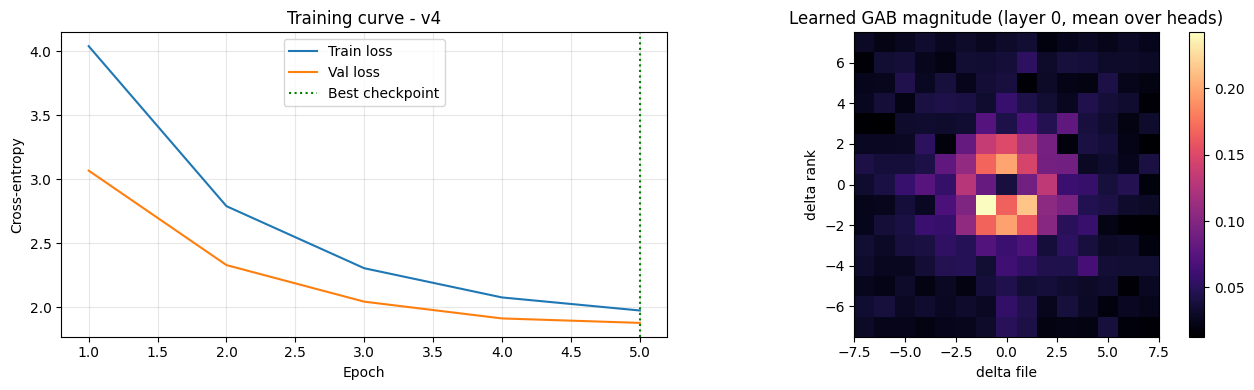

In [27]:
epochs, tr_losses, va_losses = zip(*history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs, tr_losses, label="Train loss")
axes[0].plot(epochs, va_losses, label="Val loss")
axes[0].axvline(int(np.argmin(va_losses)) + 1, color="green", linestyle=":", label="Best checkpoint")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy")
axes[0].set_title("Training curve - v4"); axes[0].legend(); axes[0].grid(alpha=0.3)

# What geometry did the heads actually learn? Mean |bias| per (df, dr) offset, layer 0.
if USE_GAB:
    _bias = model.blocks[0].attn.rel_bias.detach().cpu().numpy()
    _grid = np.abs(_bias[:, :225]).mean(axis=0).reshape(15, 15).T
    _im = axes[1].imshow(_grid, origin="lower", extent=[-7.5, 7.5, -7.5, 7.5], cmap="magma")
    axes[1].set_xlabel("delta file"); axes[1].set_ylabel("delta rank")
    axes[1].set_title("Learned GAB magnitude (layer 0, mean over heads)")
    fig.colorbar(_im, ax=axes[1])
else:
    axes[1].axis("off"); axes[1].set_title("GAB disabled")
plt.tight_layout(); plt.show()

---
# 9. Legal-Move-Masked Evaluation

Same protocol and the same reported numbers as v1–v3, so everything stays comparable: legal moves
come from `python-chess` replaying the actual game, the distribution is masked to them, and we check
whether the human's move lands in the masked Top-1 / Top-3.

Evaluation is naturally batched here — positions are independent, so a whole game (or several) goes
through in one forward pass with no teacher-forcing trick required.

**`unmasked_argmax_legal_rate` is no longer a board-tracking diagnostic.** In v1/v2 it measured
whether the model had inferred the board from move history (0.539 — illegal 46% of the time). v4 is
*given* the board, so this should be high; it now measures how well the bilinear head has learned
legality. Read it as a sanity check, never as the improvement.

In [28]:
@torch.no_grad()
def evaluate_masked_topk(records, k_values=(1, 3), max_games_eval=None, desc="Evaluating"):
    model.eval()
    hits = {k: 0 for k in k_values}
    total = 0
    unmasked_legal_argmax = 0

    subset = records if max_games_eval is None else records[:max_games_eval]

    for rec in tqdm(subset, desc=desc):
        data, legal_per_pos = extract_game_positions(rec, with_legal=True)
        target = data.pop("target")
        batch = {k: torch.from_numpy(v).to(device) for k, v in data.items()}

        logits = model(**batch)                                   # (T, V)
        probs = F.softmax(logits.float(), dim=-1).cpu().numpy()

        for t in range(len(target)):
            legal_ids = legal_per_pos[t]
            if not legal_ids:
                continue
            p = probs[t]

            if int(p.argmax()) in set(legal_ids):
                unmasked_legal_argmax += 1

            ranked = [legal_ids[i] for i in np.argsort(-p[legal_ids])]
            for k in k_values:
                if target[t] in ranked[:k]:
                    hits[k] += 1
            total += 1

    results = {f"top_{k}": hits[k] / max(1, total) for k in k_values}
    results["unmasked_argmax_legal_rate"] = unmasked_legal_argmax / max(1, total)
    results["positions_evaluated"] = total
    return results


def report(name, res):
    print(f"{name}:")
    for k, v in res.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


t0 = time.time()
eval_test = evaluate_masked_topk(test_records, max_games_eval=EVAL_MAX_GAMES, desc="Test")
report("Held-out (test) games", eval_test)

eval_train = evaluate_masked_topk(train_records, max_games_eval=EVAL_MAX_GAMES, desc="Train")
report("\nTrain games (same sample size, for the overfit gap)", eval_train)

print(f"\nTrain/test Top-1 gap: {eval_train['top_1'] - eval_test['top_1']:.4f}")
print(f"Evaluation took {time.time() - t0:.1f}s for "
      f"{eval_test['positions_evaluated'] + eval_train['positions_evaluated']} positions")

Test: 100%|██████████| 1500/1500 [01:08<00:00, 22.02it/s]


Held-out (test) games:
  top_1: 0.4303
  top_3: 0.7096
  unmasked_argmax_legal_rate: 0.9817
  positions_evaluated: 122275


Train: 100%|██████████| 1500/1500 [01:08<00:00, 22.06it/s]


Train games (same sample size, for the overfit gap):
  top_1: 0.4504
  top_3: 0.7266
  unmasked_argmax_legal_rate: 0.9825
  positions_evaluated: 122804

Train/test Top-1 gap: 0.0201
Evaluation took 136.1s for 245079 positions


In [29]:
# --- Cross-version comparison. Fill in your own v2/v3 numbers. ---
RESULTS = [
    ("v1 (move tokens, 5 ep)", {"top_1": 0.2693, "top_3": 0.4393, "unmasked_argmax_legal_rate": 0.5393}),
    ("v2 (+ELO avg)",          {"top_1": 0.2900, "top_3": None,   "unmasked_argmax_legal_rate": None}),
    ("v3 (flat board+meta)",   {"top_1": None,   "top_3": None,   "unmasked_argmax_legal_rate": None}),
    ("v4 (squares+GAB)",       eval_test),
]

print(f"{'Model':<26} {'Top-1':>8} {'Top-3':>8} {'unmasked legal':>16}")
print("-" * 62)
for name, r in RESULTS:
    fmt = lambda v: f"{v:.4f}" if isinstance(v, float) else "     -"
    print(f"{name:<26} {fmt(r.get('top_1')):>8} {fmt(r.get('top_3')):>8} "
          f"{fmt(r.get('unmasked_argmax_legal_rate')):>16}")

Model                         Top-1    Top-3   unmasked legal
--------------------------------------------------------------
v1 (move tokens, 5 ep)       0.2693   0.4393           0.5393
v2 (+ELO avg)                0.2900        -                -
v3 (flat board+meta)              -        -                -
v4 (squares+GAB)             0.4303   0.7096           0.9817


---
# 10. Save Artifacts

v4-specific filenames, so nothing here can overwrite v1/v2's shared `chess_gpt_baseline.pt` or v3's
checkpoint. The architecture config is saved alongside the weights because the checkpoint cannot be
rebuilt without it — GAB bucket count, token count and the head geometry all have to match.

In [30]:
torch.save(model.state_dict(), CKPT_PATH)

with open(VOCAB_PATH, "w") as f:
    json.dump({
        "itos": itos,
        "arch": "chessformer-v4",
        "d_model": D_MODEL, "n_head": N_HEAD, "n_layer": N_LAYER,
        "use_gab": bool(USE_GAB),
        "use_history": bool(USE_HISTORY), "k_history": K_HISTORY,
        "use_square_aux": bool(USE_SQUARE_AUX),
        "state_dim": STATE_DIM, "meta_dim": META_DIM, "aux_dim": AUX_DIM,
        "min_elo": MIN_ELO, "max_elo": MAX_ELO,
        "has_clock_data": bool(HAS_CLOCK_DATA),
    }, f)

print(f"Saved weights to      {CKPT_PATH}")
print(f"Saved vocab/config to {VOCAB_PATH}")

Saved weights to      chess_gpt_v4.pt
Saved vocab/config to chess_move_vocab_v4.json


---
# 11. Summary & Next Steps

## What v4 changes

| | |
|---|---|
| **Framing** | Positional, not autoregressive. One position -> one move, no `BLOCK_SIZE` truncation. |
| **Board** | 64 square tokens with self-attention, replacing v3's flat 1167-dim `Linear`. The scale-imbalance failure is structurally impossible now. |
| **Geometry** | Learned per-head bias over all 225 `(delta_file, delta_rank)` square relationships. |
| **Head** | Bilinear from-square x to-square + promotion bias; moves sharing a square share parameters. |
| **Padding** | None anywhere. |

## Read the results in this order

1. **Test Top-1 vs v2's 0.2900 and your v3 number.** The headline.
2. **Train/test Top-1 gap.** v4 has a better inductive bias but is still data-starved; if the gap is
   wide, the answer is games, not architecture.
3. **The GAB heatmap.** If the learned bias is essentially flat, GAB is not earning its place and
   `USE_GAB=False` should cost nothing. If it shows diagonal ridges or knight-offset hot spots, the
   model found real geometry — that plot is the most interpretable artifact in any of these
   notebooks.
4. **`unmasked_argmax_legal_rate`** as a sanity check only, for the reason in Section 9.

## Experiments, in the order I would run them

1. **`USE_SQUARE_AUX = True`.** The direct test of v4's thesis. If hand-fed attack/legality maps add
   nothing on top of attention + GAB, the architecture is doing its job and v3's feature engineering
   was compensating for a missing inductive bias. If they still help, keep them.
2. **`USE_GAB = False`.** Isolates the geometric bias from the square-token framing. These two are
   easy to conflate and they are separate claims.
3. **`USE_HISTORY = False`.** Maia-style models use no history at all. This measures how much move
   history is really worth for *human* prediction once the board is fully visible.
4. **More data.** Unchanged as the biggest lever. Better inductive bias buys sample efficiency, which
   makes data *more* valuable here, not less.
5. **Scale the model** — last, and only after the data. `N_LAYER`/`D_MODEL` are the knobs; the
   published Chessformer results use ~79M parameters against millions of games, which is roughly
   1000x this notebook's data.

## Not implemented, deliberately

**Skill-aware attention.** Maia-2's contribution is conditioning *through the attention mechanism*
rather than as an additive token. v4 feeds ELO as one global token, which is the simple version. If
rating conditioning turns out to matter here, that is the next thing to build.

**Colour-relative encoding.** Flipping the board for Black would halve what the model must learn,
but it interacts with GAB (the bias buckets become side-relative) and with the policy head. Worth
doing as its own change, not folded into this one.